## Импорт библиотек

In [20]:
import os
import math
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium

from maps_api.yandex import YandexMapsClient
from maps_api.nominatim import NominatimClient
from maps_api.overpass import OverpassClient

from config import YANDEX_MAPS_API_KEY

## Первый взгляд на данные

In [13]:
df_raw = pd.read_csv("dataset/train.csv")
df_raw.head()

,Unnamed: 0,id,atm_group,address,address_rus,lat,long,target
0,0,8526.0,32.0,"EMELYANOVA,34 Y-SAKHALINSK","улица А.О. Емельянова, 34, Южно-Сахалинск, Сах...",46.940995,142.738319,0.011500
1,1,8532.0,32.0,"KOMSOMOLSKAYA,259B Y.SAKHALINSK","Комсомольская улица, 259, Южно-Сахалинск, Саха...",46.937353,142.753348,0.029710
2,2,8533.0,32.0,"KOMMUN. PR., 32 YUZHNO SAKHAL","Коммунистический проспект, Южно-Сахалинск, Сах...",46.959413,142.741113,0.009540
3,3,8684.0,32.0,"LENINGRADSKIY PR.,76A MOSCOW","Ленинградский проспект, 76А, Москва, Россия, 1...",55.805827,37.515146,-0.094035
4,4,37.0,32.0,"GVARDEYSKAYA PL., 2 NORILSK","Гвардейская площадь, 2, Норильск, Красноярский...",69.343541,88.211228,0.079277


## Очистка от выбросов

### Восстановление неполных данных

In [ ]:
df_corrupted = df_raw[df_raw.isnull().any(axis=1)].reset_index(drop=True)
df_corrupted = df_corrupted.drop(columns=[df_raw.columns[0]])   # drop old indecies
df_corrupted.head()

In [ ]:
if len(df_corrupted) > 0:
    print("\n=== Missing fields statistics ===")
    for col in df_raw.columns:
        missing_in_col = df_raw[col].isnull().sum()
        if missing_in_col > 0:
            print(f"Column '{col}': {missing_in_col} missing values")

В каждой строке отсутсвуют адрес на русском и координаты. Восстановим данные через Яндекс Карты.

In [ ]:
def get_address_data(address: str) -> tuple[str, float, float]:
    client = YandexMapsClient(YANDEX_MAPS_API_KEY)
    address_lst = address.split()
    if "G" in address_lst:
        address_lst.remove("G")
    address_lst.insert(0, address_lst.pop())
    
    formatted_address = " ".join(address_lst)
    geodata = client.get_geodata(address=formatted_address)
    if not geodata:
        return None, None, None
    for fm in geodata.feature_member:
        if fm.geo_object.meta_data_property.geocoder_meta_data.address.country_code == "RU":
            address_comp = fm.geo_object.meta_data_property.geocoder_meta_data.address.components
            address_comp[-1], address_comp[-2] = address_comp[-2], address_comp[-1]
            address_comp.reverse()
            address_rus = ", ".join([x.name for x in address_comp])
            long, lat = fm.geo_object.point.pos.split()
            return address_rus, float(long), float(lat)
    return None, None, None

In [ ]:
df_fixed = df_corrupted.copy()
success_count = 0
failed_count = 0

for index, row in df_fixed.iterrows():
    address = row['address']
    try:
        address_rus, long, lat = get_address_data(address)
        if address_rus is not None and lat is not None and long is not None:
            df_fixed.at[index, 'address_rus'] = address_rus
            df_fixed.at[index, 'lat'] = lat
            df_fixed.at[index, 'long'] = long
            success_count += 1
        else:
            print(f"Partial data for: {address}")
            failed_count += 1
    except Exception as e:
        print(f"Error with '{address}': {e}")
        failed_count += 1

print(f"\n=== Summary ===")
print(f"Successfully fixed: {success_count}")
print(f"Failed/Partial: {failed_count}")
print(f"Total processed: {len(df_fixed)}")

Сохраняем в csv для ручной валидации

In [ ]:
FILE_NAME = "temp/atm_data_fixed_for_validation.csv"

df_fixed.to_csv(f"{FILE_NAME}", index=False, encoding='utf-8')

print(f"Saved {len(df_fixed)} rows to '{FILE_NAME}'")

Загружаем отвалидированные данные

In [14]:
df_fixed_validated = pd.read_csv("temp/atm_data_fixed_validated.csv", encoding='utf-8')

### Валидация полных данных

In [ ]:
df_clean = df_raw.dropna()
df_clean.head()

,Unnamed: 0,id,atm_group,address,address_rus,lat,long,target
0,0,8526.0,32.0,"EMELYANOVA,34 Y-SAKHALINSK","улица А.О. Емельянова, 34, Южно-Сахалинск, Сах...",46.940995,142.738319,0.011500
1,1,8532.0,32.0,"KOMSOMOLSKAYA,259B Y.SAKHALINSK","Комсомольская улица, 259, Южно-Сахалинск, Саха...",46.937353,142.753348,0.029710
2,2,8533.0,32.0,"KOMMUN. PR., 32 YUZHNO SAKHAL","Коммунистический проспект, Южно-Сахалинск, Сах...",46.959413,142.741113,0.009540
3,3,8684.0,32.0,"LENINGRADSKIY PR.,76A MOSCOW","Ленинградский проспект, 76А, Москва, Россия, 1...",55.805827,37.515146,-0.094035
4,4,37.0,32.0,"GVARDEYSKAYA PL., 2 NORILSK","Гвардейская площадь, 2, Норильск, Красноярский...",69.343541,88.211228,0.079277


Проверяем соответсвие ру адреса и координат

In [2]:
COORDS_THRESHOLD = 0.001  # ~100m


def get_ru_address_coords(address: str) -> tuple[float, float]:
    client = YandexMapsClient(YANDEX_MAPS_API_KEY)
    geodata = client.get_geodata(address=address)
    if not geodata:
        return None, None
    for fm in geodata.feature_member:
        if fm.geo_object.meta_data_property.geocoder_meta_data.address.country_code == "RU":
            long, lat = fm.geo_object.point.pos.split()
            return float(long), float(lat)
    return None, None


def validate_coords(
    coords_a: tuple[float, float],
    coords_b: tuple[float, float],
    threshold: float = COORDS_THRESHOLD
) -> bool:
    lat_a, long_a = coords_a
    lat_b, long_b = coords_b
    lat_diff = lat_a - lat_b
    long_diff = long_a - long_b
    distance = math.sqrt(lat_diff**2 + long_diff**2)
    return distance <= threshold

In [15]:
VALIDATED_DATA_FILE = "temp/atm_clean_validated.csv"

if os.path.exists(VALIDATED_DATA_FILE):
    df_clean_validated = pd.read_csv(VALIDATED_DATA_FILE, encoding='utf-8')

else:
    df_clean_validated = df_clean.copy()
    df_clean_validated["checked"] = 0
    df_clean_validated["valid"] = 0

In [ ]:
MAX_API_REQUESTS = 1000

success_count = 0
failed_count = 0

api_counter = 0
for index, row in df_clean_validated.iterrows():
    if api_counter > MAX_API_REQUESTS - 1:
        break
    address = row['address_rus']
    if int(row['checked']) == 1:
        continue
    try:
        api_long, api_lat = get_ru_address_coords(address)
        api_counter += 1
        if api_lat is None and api_long is None:
            print(f"Bad API response for: {address}")
            df_clean_validated.at[index, 'valid'] = 1
            success_count += 1
            break
        address_long = float(df_clean_validated.at[index, 'long'])
        address_lat = float(df_clean_validated.at[index, 'lat'])
        if validate_coords((api_long, api_lat), (address_long, address_lat)):
            df_clean_validated.at[index, 'valid'] = 1
            success_count += 1
        else:
            print(f"Wrong coords for: {address}")
            df_clean_validated.at[index, 'valid'] = 0
            failed_count += 1
    except Exception as e:
        print(f"Error with '{address}': {e}")
        failed_count += 1
    finally:
        df_clean_validated.at[index, 'checked'] = 1

print(f"\n=== Summary ===")
print(f"Successfully validated: {success_count}")
print(f"Failed: {failed_count}")
df_clean_validated.to_csv(f"{VALIDATED_DATA_FILE}", index=False, encoding='utf-8')
print("Data saved")

Wrong coords for: Ленинградский проспект, 39с3, Москва, Россия, 125167
Wrong coords for: Индустриальная улица, 3, Лиски, Воронежская область, Россия, 397908
Wrong coords for: Ивановская улица, 4, Владивосток, Приморский край, Россия, 690005
Wrong coords for: Иркутск-45, Аларский район, Иркутская область, Россия
Wrong coords for: проспект Вернадского, 78, Москва, Россия, 119454
Wrong coords for: улица Чульдум, 18, Кызыл, Республика Тыва, Россия, 667000
Wrong coords for: улица Героя Шапошникова, 5, Нижний Новгород, Россия, 603152
Wrong coords for: улица Ленина, 1, Заполярный, Печенгский район, Мурманская область, Россия, 184430
Wrong coords for: поселок Сергиевский, Саратовский район, Саратовская область, Россия
Wrong coords for: Набережная улица, 39, Сретенск, Забайкальский край, Россия, 673500
Wrong coords for: Октябрьская улица, 141, станица Тбилисская, Тбилисский район, Краснодарский край, Россия, 352360
Wrong coords for: улица Ленина, 58, посёлок городского типа Агинское, Забайкальс

In [16]:
columns_to_keep = ['id', 'atm_group', 'address', 'address_rus', 'lat', 'long', 'target']
df_invalid = df_clean_validated[df_clean_validated['valid'] == 0][columns_to_keep]
df_valid = df_clean_validated[df_clean_validated['valid'] == 1][columns_to_keep]
len(df_invalid)

237

Дополнительно проверим координаты, непрошедшие валидацию через Яндекс Карты, с помощью Nominatim OSM API. В ручную сравним адрес из датасета с адресом из Nominatim, полученным по координатам.

In [ ]:
def get_osm_address_by_coords(
    long: float,
    lat: float,
    client: NominatimClient
) -> str:
    data = client.get_geodata_by_coords(long=long, lat=lat)
    if not data:
        return "Missing data"
    else:
        return data.address.address_str

In [10]:
INVALID_DF_SAVE_PATH = "temp/atm_clean_invalid.csv"


df_invalid["address_osm"] = None

client = NominatimClient()


for index, row in df_invalid.iterrows():
    try:
        long = float(df_invalid.at[index, 'long'])
        lat = float(df_invalid.at[index, 'lat'])
        address_osm = get_osm_address_by_coords(
            long=long,
            lat=lat,
            client=client
        )
        df_invalid.at[index, 'address_osm'] = address_osm
    except Exception as e:
        print(f"Error with '{address}': {e}")


df_invalid.to_csv(f"{INVALID_DF_SAVE_PATH}", index=False, encoding='utf-8')
print("Data saved")

Data saved


Загружаем отвалидированные данные

In [4]:
df_invalid_fixed = pd.read_csv("temp/atm_clean_invalid_validated.csv", encoding='utf-8')

### Объединяем все данные в один датасет

In [18]:
DATASET_FILE_NAME = "dataset/atm_train.csv"

columns_to_keep = ['id', 'atm_group', 'address', 'address_rus', 'lat', 'long', 'target']
df1 = df_fixed_validated[columns_to_keep]
df2 = df_valid[columns_to_keep]
df3 = df_invalid_fixed[columns_to_keep]
combined = pd.concat([df1, df2, df3], ignore_index=True)

combined.to_csv(f"{DATASET_FILE_NAME}", index=False, encoding='utf-8')
print("Data saved")

Data saved


In [23]:
print(f"Saved: {(len(combined) / len(df_raw) * 100):.2f}% of data")
print(f"Lost: {len(df_raw) - len(combined)} addresses")

Saved: 97.16% of data
Lost: 178 addresses


По итогам валидации и очистки данных было потеряно менее 3% адресов

## Распределение целевой переменной

Загрузим очищенный датасет

In [33]:
df = pd.read_csv("dataset/atm_train.csv", encoding='utf-8')

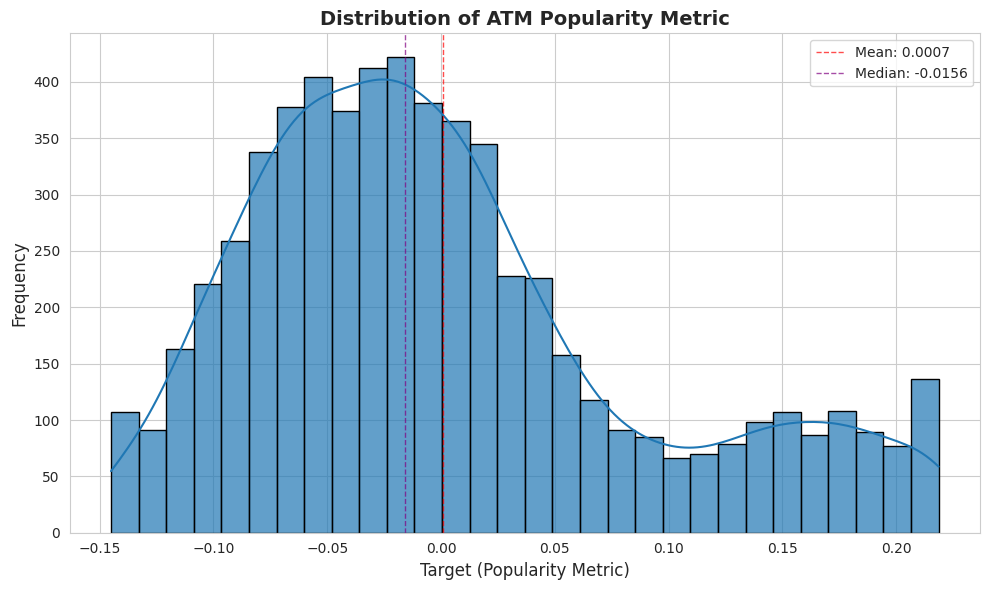

=== Statistics ===
Mean: 0.0007
Median: -0.0156
Min: -0.1450
Max: 0.2186
Std Dev: 0.0860
Skewness: 0.8085
Range: [-0.1450, 0.2186]
Negative values: 3535 / 6083 (58.1%)


In [37]:
plt.style.use('default')
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(data=df, x='target', bins=30, kde=True, alpha=0.7, edgecolor='black')

plt.xlabel('Target (Popularity Metric)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of ATM Popularity Metric', fontsize=14, fontweight='bold')

mean_val = df['target'].mean()
median_val = df['target'].median()
plt.axvline(x=mean_val, color='red', linestyle='--', alpha=0.7, linewidth=1, label=f'Mean: {mean_val:.4f}')
plt.axvline(x=median_val, color='purple', linestyle='--', alpha=0.7, linewidth=1, label=f'Median: {median_val:.4f}')

plt.legend()
plt.tight_layout()
plt.show()

print("=== Statistics ===")
print(f"Mean: {df['target'].mean():.4f}")
print(f"Median: {df['target'].median():.4f}")
print(f"Min: {df['target'].min():.4f}")
print(f"Max: {df['target'].max():.4f}")
print(f"Std Dev: {df['target'].std():.4f}")
print(f"Skewness: {df['target'].skew():.4f}")
print(f"Range: [{df['target'].min():.4f}, {df['target'].max():.4f}]")
print(f"Negative values: {(df['target'] < 0).sum()} / {len(df)} ({(df['target'] < 0).sum()/len(df)*100:.1f}%)")

## Карта АТМ

In [34]:
russia_center = [55.7558, 37.6173]
m = folium.Map(location=russia_center, zoom_start=4)


for idx, row in df.iterrows():
    color = 'red' if row['target'] < 0 else 'green'
    
    folium.CircleMarker(
        location=[row['lat'], row['long']],
        radius=8,
        popup=f"""
        ID: {row['id']}<br>
        Address: {row['address_rus']}<br>
        Target: {row['target']:.4f}<br>
        Group: {row['atm_group']}
        """,
        tooltip=f"ATM {row['id']}",
        color=color,
        fillColor=color,
        fillOpacity=0.6
    ).add_to(m)

m.save('atm_locations_map.html')
print("Map saved as 'atm_locations_map.html'")

Map saved as 'atm_locations_map.html'


## Генерация признаков

Сбор данных происходил на сервере через Overpass и Nominatim API

In [14]:
TEST_COORDS = {
    "lat": 55.666624,
    "long": 37.51573
}

overpass_client = OverpassClient()
nominatim_client = NominatimClient()

### Категорий строений в радиусе АТМ


**Магазины с наличными**: киоск, газетный киоск, табачный, лотерея, ломбард, ростовщик, благотворительность

**Религиозные здания**: церковь, собор, часовня, мечеть, храм, синагога, святыня, монастырь, место поклонения

**Рынки торговцы**: рынок, торговый автомат

**Еда напитки**: ресторан, кафе, фастфуд, фудкорт, мороженое, бар, паб

**Транспорт**: автобусная станция, железнодорожная станция, такси, паромный терминал, прокат велосипедов

**Туризм**: отель, хостел, гостевой дом, мотель

**Личные услуги**: парикмахерская, салон красоты, барбершоп, массаж, портной, прачечная, химчистка

**Образование**: университет, колледж, школа, детский сад

**Финансовые услуги**: банк, пункт обмена валюты, банкомат

**Крупная розница**: торговый центр, универмаг, супермаркет

**Развлечения**: кинотеатр, театр, казино, ночной клуб

**Общественные объекты**: библиотека, общественный центр, почтовое отделение, полиция, здание суда

**Здравоохранение**: больница, клиника, аптека, стоматолог

In [4]:
RADII = [100, 250, 500, 1000]

SURROUNDING_TYPES = ['personal_services', 'large_retail', 'transportation', 'religious_buildings', 'food_drink', 'cash_intensive_shops', 'healthcare', 'education', 'entertainment', 'markets_vendors', 'financial_services', 'tourism', 'public_amenities']

In [6]:
def get_surroundings_with_radius() -> list[str]:
    result = []
    for radius in RADII:
        for sur in SURROUNDING_TYPES:
            result.append(f"{sur}_{radius}")
    return result

Пример запроса:

In [15]:
QUERY_CATEGORIES = {
    'shop': [
        'convenience', 'kiosk', 'newsagent', 'tobacco',
        'lottery', 'pawnbroker', 'money_lender', 'charity',
        'mall', 'department_store', 'supermarket',
        'hairdresser', 'beauty', 'barber', 'massage',
        'tailor', 'laundry', 'dry_cleaning'
    ],
    
    'amenity': [
        'marketplace', 'vending_machine',
        'restaurant', 'cafe', 'fast_food', 'food_court',
        'ice_cream', 'bar', 'pub',
        'cinema', 'theatre', 'casino', 'nightclub',
        'bus_station', 'train_station', 'taxi',
        'ferry_terminal', 'bicycle_rental',
        'university', 'college', 'school', 'kindergarten',
        'library', 'community_centre', 'post_office',
        'police', 'courthouse', 'place_of_worship',
        'hospital', 'clinic', 'pharmacy', 'dentist',
        'bank', 'bureau_de_change', 'atm'
    ],
    
    'tourism': [
        'hotel', 'hostel', 'guest_house', 'motel'
    ],
    
    'building': [
        'church', 'cathedral', 'chapel', 'mosque', 
        'temple', 'synagogue', 'shrine', 'monastery'
    ]
}

print(overpass_client.count_categories(
    long=TEST_COORDS["long"],
    lat=TEST_COORDS["lat"],
    radius=500,
    categories=QUERY_CATEGORIES
))

{'shop': POICountResult(success=True, total=29, counts={'convenience': 3, 'kiosk': 0, 'newsagent': 0, 'tobacco': 0, 'lottery': 0, 'pawnbroker': 2, 'money_lender': 0, 'charity': 0, 'mall': 1, 'department_store': 0, 'supermarket': 7, 'hairdresser': 3, 'beauty': 8, 'barber': 0, 'massage': 0, 'tailor': 2, 'laundry': 0, 'dry_cleaning': 3}, category='shop', elements_found=152, error=None, coordinates={'lat': 55.666624, 'lon': 37.51573}, radius=500.0), 'amenity': POICountResult(success=True, total=51, counts={'marketplace': 0, 'vending_machine': 0, 'restaurant': 5, 'cafe': 5, 'fast_food': 5, 'food_court': 1, 'ice_cream': 0, 'bar': 0, 'pub': 0, 'cinema': 2, 'theatre': 0, 'casino': 0, 'nightclub': 0, 'bus_station': 0, 'train_station': 0, 'taxi': 0, 'ferry_terminal': 0, 'bicycle_rental': 0, 'university': 0, 'college': 0, 'school': 1, 'kindergarten': 6, 'library': 1, 'community_centre': 0, 'post_office': 2, 'police': 1, 'courthouse': 0, 'place_of_worship': 0, 'hospital': 0, 'clinic': 1, 'pharmacy

### Тип ближайшей дороги и расстояние до нее

**highway_type**: unknown, footway, service, steps, residential, tertiary,
 secondary, living_street, corridor, unclassified, trunk_link,
 secondary_link, primary, path, pedestrian, track, trunk,
 tertiary_link, rest_area, cycleway, primary_link, bus_stop,
 platform, elevator, raceway, road, motorway, proposed

Пример запроса:

In [16]:
print(overpass_client.get_nearest_highway_context(
    long=TEST_COORDS["long"],
    lat=TEST_COORDS["lat"]
))

highway_type='service' highway_name=None distance_meters=67.29226149317459 nearest_highway_id=39947388 success=True error=None


### Парковки

Данные включают в себя: типы парковок, их количество и расстояние до ближайшей

Пример запроса:

In [17]:
print(overpass_client.get_parking_context(
    long=TEST_COORDS["long"],
    lat=TEST_COORDS["lat"]
))

parking_count=3 parking_types=['parking'] nearest_parking_distance=31.858573734063526 parking_capacity=None success=True error=None


### Общественный транспорт

Количество станций метро в округе, расстояние до ближайшей, количество автобусных и трамвайных остановок, расстояние до ближайщей автобусной остановки

Пример запроса:

In [18]:
print(overpass_client.get_transportation_context(
    long=TEST_COORDS["long"],
    lat=TEST_COORDS["lat"]
))

metro_stations_count=1 metro_station_names=[] nearest_metro_distance=471.5441127089353 nearest_metro_name=None bus_stops_count=6 tram_stops_count=0 nearest_bus_distance=111.48307938545675 total_public_transport=7 has_major_transport_hub=True success=True error=None


### Город и регион

Пример запроса:

In [19]:
print(nominatim_client.get_administrative_context(
    long=TEST_COORDS["long"],
    lat=TEST_COORDS["lat"]
))

city='Москва' city_population=None region='Москва' country='Россия' postcode='119421' is_urban=True success=True error=None


## Анализ собранных признаков

In [5]:
df_extended = pd.read_csv("dataset/atm_train_extended.csv", encoding='utf-8')

### Зависимость группы банкомата от его популярности

=== ATM Group Analysis ===
Number of unique ATM groups: 7
ATM group value counts:
atm_group
5478.0    2592
1942.0    1119
8083.0    1019
496.5      611
3185.5     569
1022.0     131
32.0        42
Name: count, dtype: int64


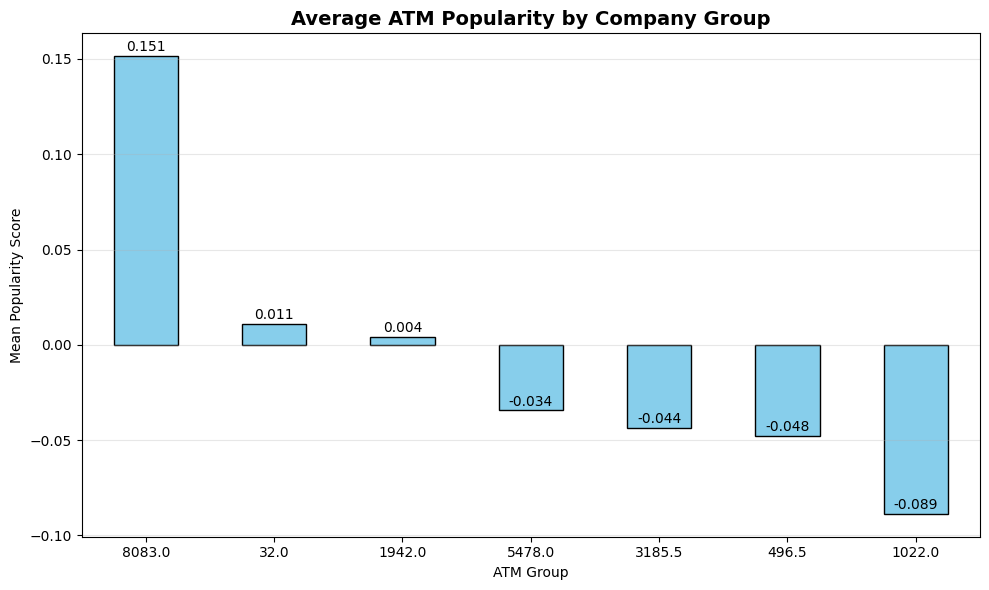

In [24]:
print("=== ATM Group Analysis ===")
print(f"Number of unique ATM groups: {df_extended['atm_group'].nunique()}")
print(f"ATM group value counts:")
print(df_extended['atm_group'].value_counts())

group_means = df_extended.groupby('atm_group')['target'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
group_means.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Average ATM Popularity by Company Group', fontsize=14, fontweight='bold')
plt.xlabel('ATM Group')
plt.ylabel('Mean Popularity Score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(group_means):
    plt.text(i, v + 0.001, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Корреляция для разных категорий строений

In [22]:
features = get_surroundings_with_radius() + ["target"]
target_correlations = df_extended[features].corr()["target"].sort_values(ascending=False)

print("=== SURROUNDINGS CORRELATION WITH TARGET ===")
print(target_correlations)

=== SURROUNDINGS CORRELATION WITH TARGET ===
target                       1.000000
cash_intensive_shops_1000    0.105319
food_drink_250               0.098517
transportation_1000          0.096423
financial_services_250       0.095917
transportation_500           0.094063
personal_services_1000       0.093710
financial_services_500       0.091293
financial_services_1000      0.091272
food_drink_500               0.088557
personal_services_500        0.087625
food_drink_100               0.086585
cash_intensive_shops_500     0.086197
personal_services_250        0.084051
healthcare_1000              0.083668
financial_services_100       0.079360
food_drink_1000              0.073905
healthcare_500               0.070995
public_amenities_1000        0.067113
entertainment_500            0.066214
entertainment_1000           0.066175
transportation_250           0.065245
entertainment_250            0.055553
healthcare_250               0.050899
markets_vendors_1000         0.049389
perso

Features in the correlation matrix:
['target', 'cash_intensive_shops_1000', 'food_drink_250', 'transportation_1000', 'financial_services_250', 'transportation_500']


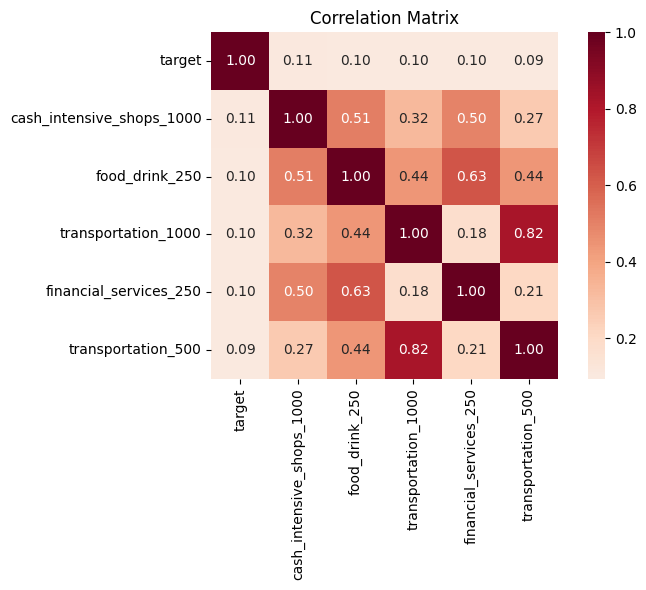

In [28]:
top_5_features = target_correlations.index[1:6]

features_to_plot = ['target'] + top_5_features.tolist()

print("Features in the correlation matrix:")
print(features_to_plot)

corr_top_features = df_extended[features_to_plot].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_top_features, 
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=True)

plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Анализ дорог

Средняя популярность для типов дорог

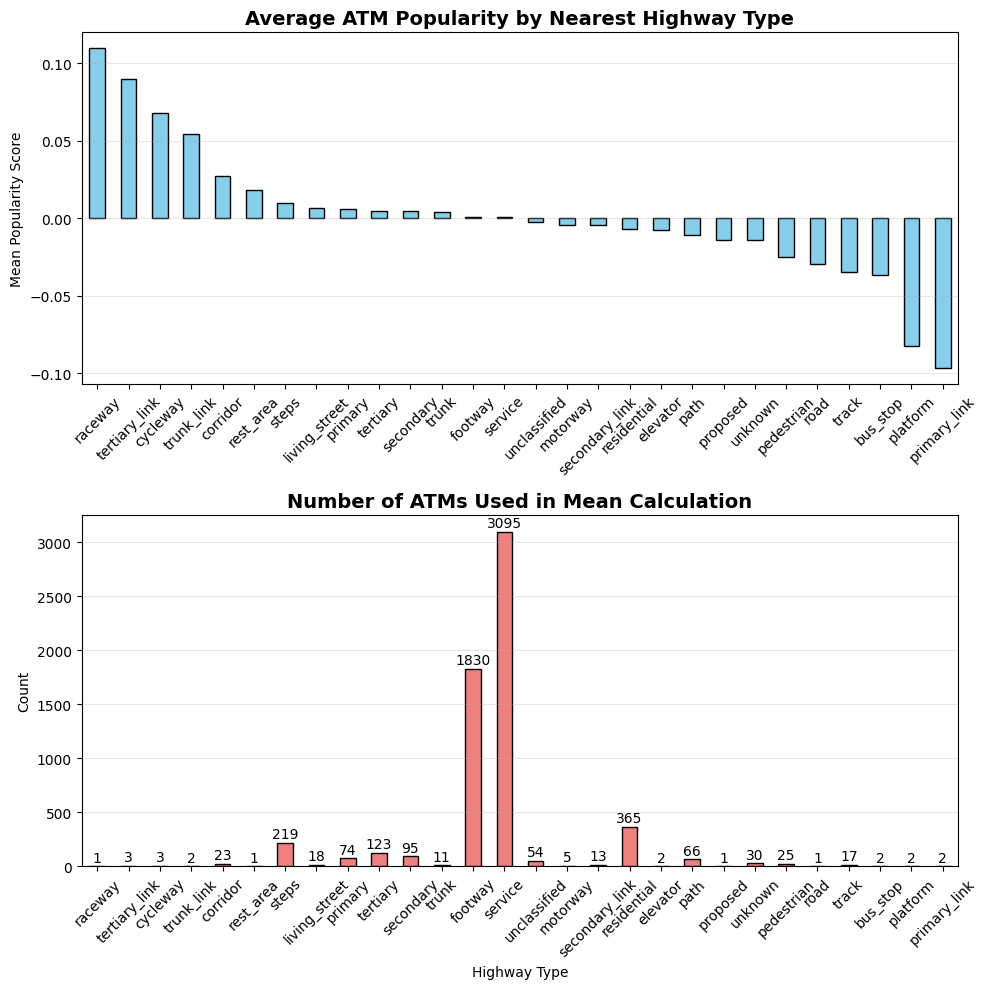

In [35]:
group_means = df_extended.groupby('highway_type')['target'].mean().sort_values(ascending=False)
group_counts = df_extended.groupby('highway_type')['target'].count()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

group_means.plot(kind='bar', color='skyblue', edgecolor='black', ax=ax1)
ax1.set_title('Average ATM Popularity by Nearest Highway Type', fontsize=14, fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Mean Popularity Score')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)

group_counts.reindex(group_means.index).plot(kind='bar', color='lightcoral', edgecolor='black', ax=ax2)
ax2.set_title('Number of ATMs Used in Mean Calculation', fontsize=14, fontweight='bold')
ax2.set_xlabel('Highway Type')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

for i, v in enumerate(group_counts.reindex(group_means.index)):
    ax2.text(i, v + max(group_counts)*0.005, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Корреляция с расстоянием:

In [9]:
highway_df = df_extended[df_extended["highway_distance"] != 0.0]
highway_correlations = highway_df[["highway_distance", "target"]].corr()["target"].sort_values(ascending=False)
print(highway_correlations)

target              1.000000
highway_distance   -0.009928
Name: target, dtype: float64


### Анализ парковок

Корреляция с количеством парковок и расстоянием до ближайшей:

In [14]:
parking_df = df_extended[df_extended["parking_count"] != 0]
parking_correlations = parking_df[["parking_count", "parking_distance", "target"]].corr()["target"].sort_values(ascending=False)
print(parking_correlations)

target              1.000000
parking_count       0.063057
parking_distance    0.050626
Name: target, dtype: float64


Типы парковок:

In [17]:
parking_types_count = {}
parking_types_sum = {}
parking_types_mean = {}

for index, row in parking_df.iterrows():
    for parking_type in json.loads(parking_df.at[index, "parking_types"]):
        if parking_type in parking_types_count:
            parking_types_count[parking_type] += 1
            parking_types_sum[parking_type] += float(parking_df.at[index, "target"])
        else:
            parking_types_count[parking_type] = 1
            parking_types_sum[parking_type] = float(parking_df.at[index, "target"])

for pt, value in parking_types_sum.items():
    parking_types_mean[pt] = value / parking_types_count[pt]

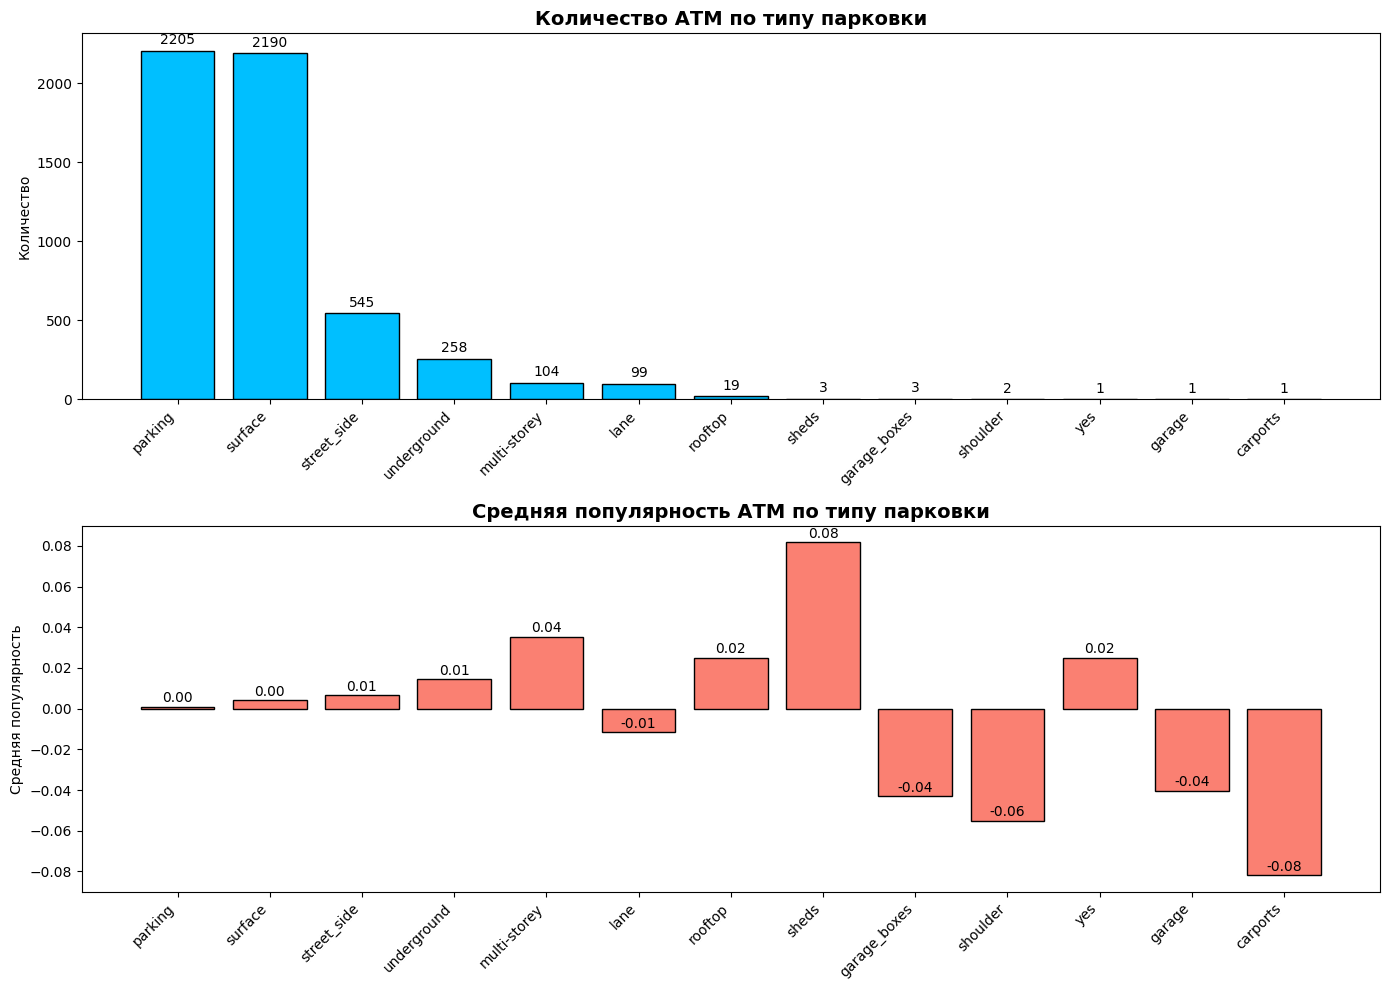

In [ ]:
sorted_types = sorted(parking_types_count, key=parking_types_count.get, reverse=True)
counts = [parking_types_count[pt] for pt in sorted_types]
means = [parking_types_mean[pt] for pt in sorted_types]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.bar(sorted_types, counts, color='deepskyblue', edgecolor='black')
ax1.set_title('Количество АТМ по типу парковки', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество')
ax1.set_xticks(np.arange(len(sorted_types)))
ax1.set_xticklabels(sorted_types, rotation=45, ha='right')
for i, v in enumerate(counts):
    ax1.text(i, v + max(counts)*0.01, str(v), ha='center', va='bottom', fontsize=10)

ax2.bar(sorted_types, means, color='salmon', edgecolor='black')
ax2.set_title('Средняя популярность АТМ по типу парковки', fontsize=14, fontweight='bold')
ax2.set_ylabel('Средняя популярность')
ax2.set_xticks(np.arange(len(sorted_types)))
ax2.set_xticklabels(sorted_types, rotation=45, ha='right')
for i, v in enumerate(means):
    ax2.text(i, v + max(means)*0.01, f'{v:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Анализ показателей уровня развития общественного транспорта в зоне АТМ

Метро:

In [31]:
metro_df = df_extended[df_extended["metro_count"] != 0]
metro_correlations = metro_df[["metro_count", "metro_distance", "target"]].corr()["target"].sort_values(ascending=False)
print(metro_correlations)

target            1.000000
metro_distance    0.114782
metro_count       0.045015
Name: target, dtype: float64


Трамваи и автобусы:

In [32]:
bus_df = df_extended[df_extended["bus_tram_count"] != 0]
bus_correlations = bus_df[["bus_tram_count", "bus_distance", "target"]].corr()["target"].sort_values(ascending=False)
print(bus_correlations)

target            1.000000
bus_tram_count    0.118323
bus_distance     -0.012994
Name: target, dtype: float64


### Зависимость показателей от региона и города

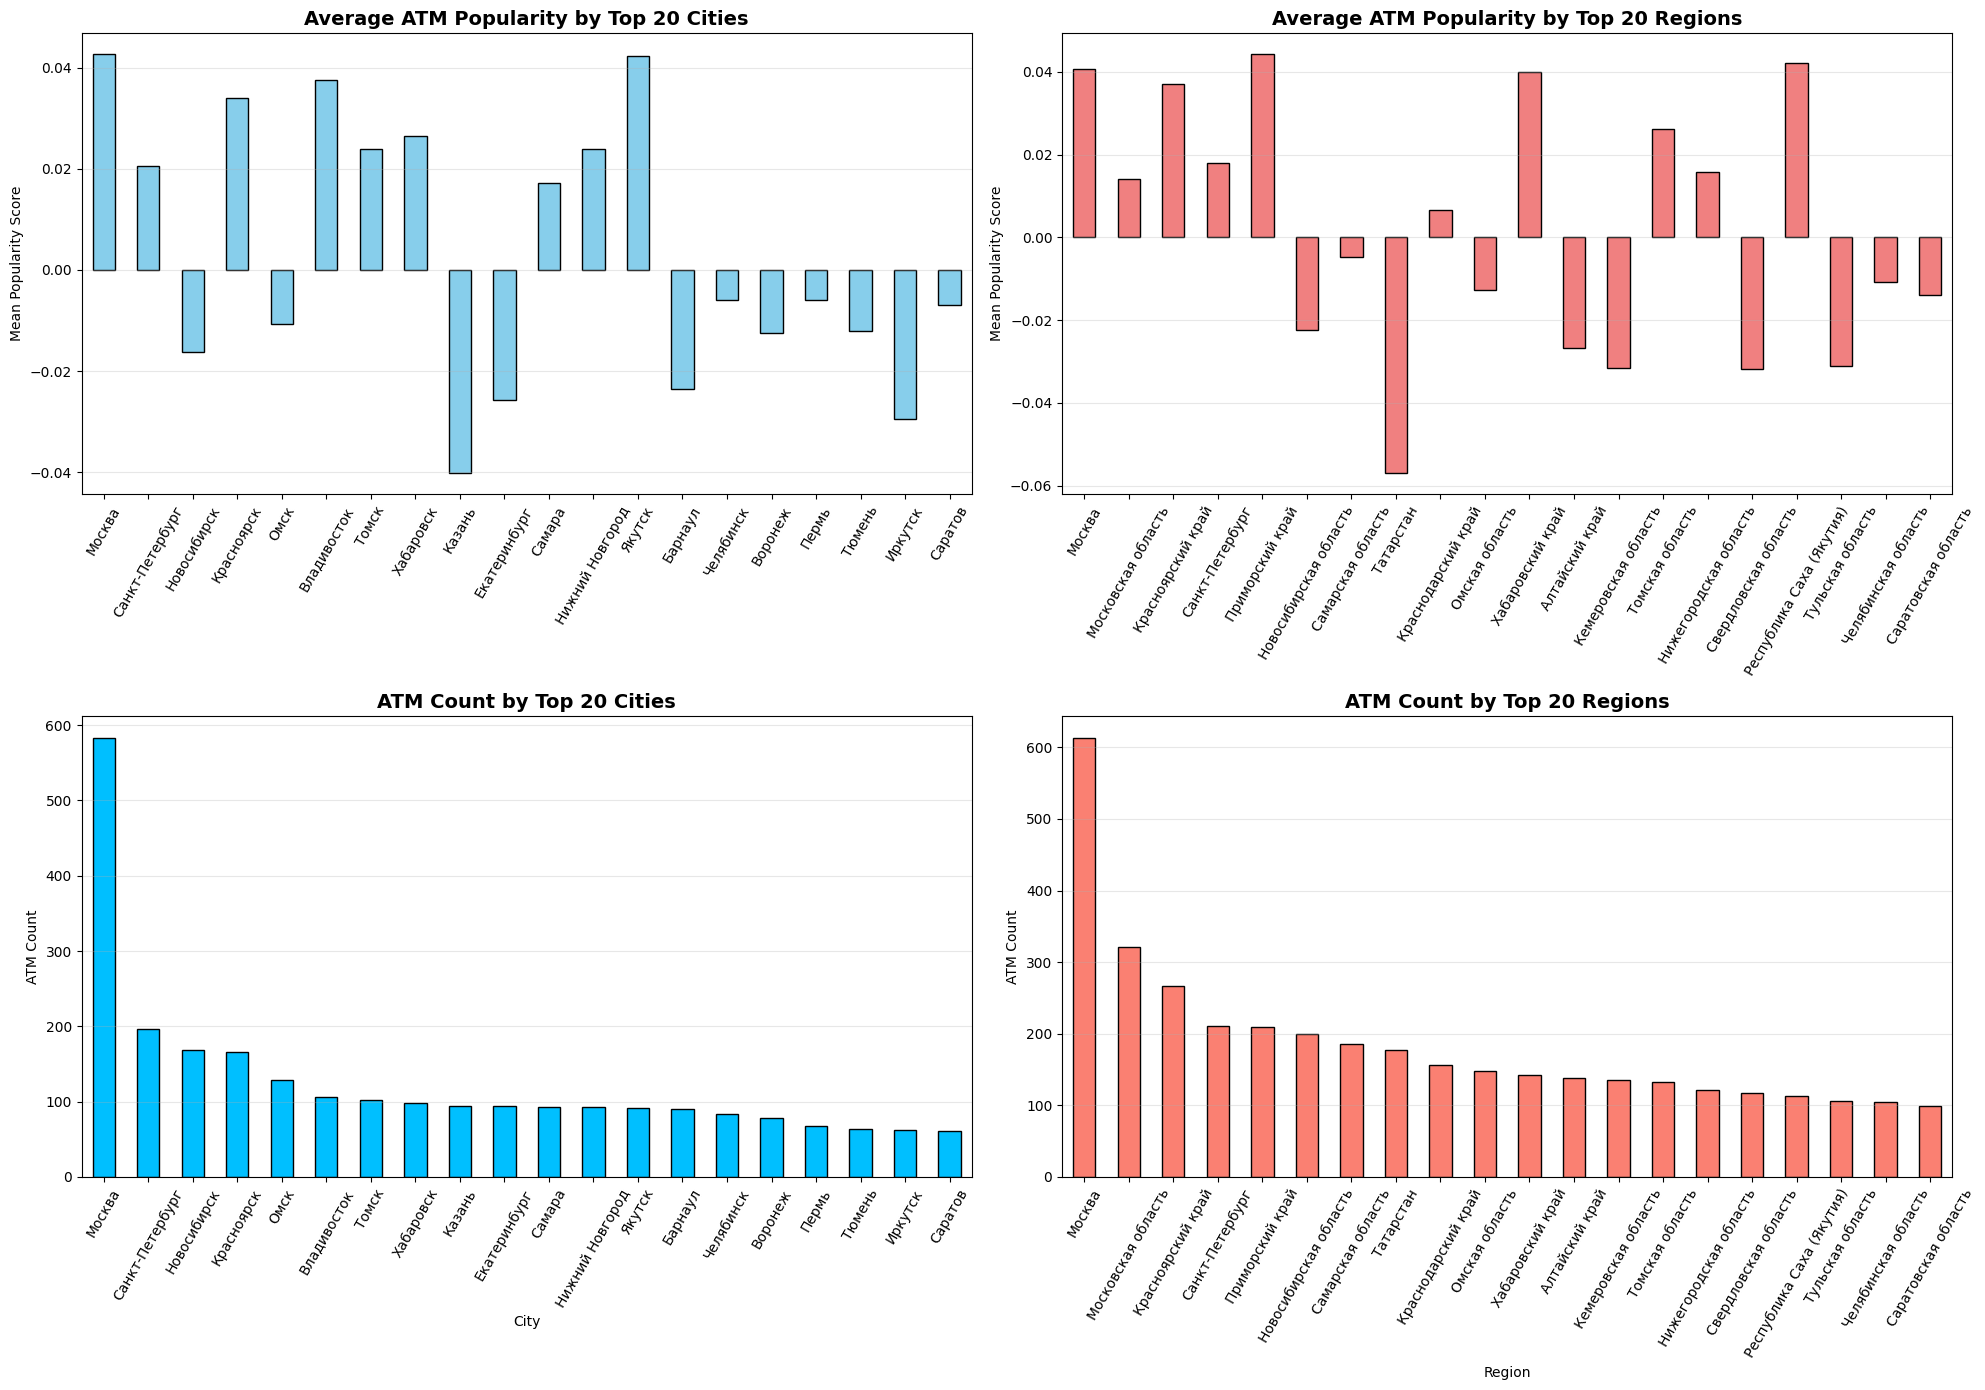

In [13]:
LIMIT = 20

city_counts = df_extended['city'].value_counts().head(LIMIT)
top_cities = city_counts.index
region_counts = df_extended['region'].value_counts().head(LIMIT)
top_regions = region_counts.index

group_city = df_extended[df_extended['city'].isin(top_cities)].groupby('city')['target'].mean().loc[top_cities]
group_region = df_extended[df_extended['region'].isin(top_regions)].groupby('region')['target'].mean().loc[top_regions]

fig, axs = plt.subplots(2, 2, figsize=(20, 14))
# City mean
group_city.plot(kind='bar', color='skyblue', edgecolor='black', ax=axs[0, 0])
axs[0, 0].set_title(f'Average ATM Popularity by Top {LIMIT} Cities', fontsize=14, fontweight='bold')
axs[0, 0].set_xlabel('')
axs[0, 0].set_ylabel('Mean Popularity Score')
axs[0, 0].tick_params(axis='x', rotation=60)
axs[0, 0].grid(axis='y', alpha=0.3)
# City count
city_counts.plot(kind='bar', color='deepskyblue', edgecolor='black', ax=axs[1, 0])
axs[1, 0].set_title(f'ATM Count by Top {LIMIT} Cities', fontsize=14, fontweight='bold')
axs[1, 0].set_xlabel('City')
axs[1, 0].set_ylabel('ATM Count')
axs[1, 0].tick_params(axis='x', rotation=60)
axs[1, 0].grid(axis='y', alpha=0.3)
# Region mean
group_region.plot(kind='bar', color='lightcoral', edgecolor='black', ax=axs[0, 1])
axs[0, 1].set_title(f'Average ATM Popularity by Top {LIMIT} Regions', fontsize=14, fontweight='bold')
axs[0, 1].set_xlabel('')
axs[0, 1].set_ylabel('Mean Popularity Score')
axs[0, 1].tick_params(axis='x', rotation=60)
axs[0, 1].grid(axis='y', alpha=0.3)
# Region count
region_counts.plot(kind='bar', color='salmon', edgecolor='black', ax=axs[1, 1])
axs[1, 1].set_title(f'ATM Count by Top {LIMIT} Regions', fontsize=14, fontweight='bold')
axs[1, 1].set_xlabel('Region')
axs[1, 1].set_ylabel('ATM Count')
axs[1, 1].tick_params(axis='x', rotation=60)
axs[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Разница показателей для городской среды:

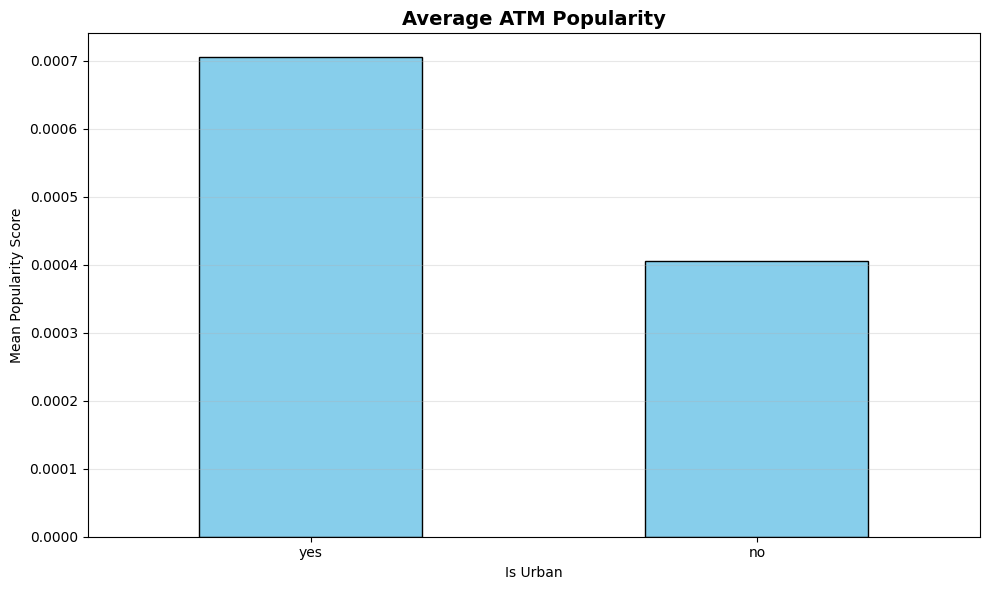

In [29]:
urban_df = df_extended[df_extended['is_urban'] != 2]
group_urban = urban_df[['is_urban', 'target']].groupby('is_urban')['target'].mean().sort_values(ascending=False)

labels = ['no' if idx == 0 else 'yes' for idx in group_urban.index]

plt.figure(figsize=(10, 6))
group_urban.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average ATM Popularity', fontsize=14, fontweight='bold')
plt.xlabel('Is Urban')
plt.ylabel('Mean Popularity Score')
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Выводы

1) Распределение целевой переменной смещено вправо. Хотя медиана отрицательная (-0.0156) и 58% банкоматов имеют популярность < 0, среднее значение близко к 0 достигается за счет правого хвоста распределения - небольшой части банкоматов с высокой популярностью.

2) Количественные признаки с наибольшей корреляцией: магазины с наличной оплатой на расстоянии до 1км, еда и напитки до 250м, близость к метро и автобусным/трамвайным остановкам.

3. Качественные признаки с наибольшим влиянием: group_id банкомата, город и регион.